In [1]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Rezultatų atkartojamumui
random.seed(67)
np.random.seed(67)
tf.random.set_seed(67)

print('TensorFlow versija:', tf.__version__)

/Users/robertajurpalyte/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TensorFlow versija: 2.20.0


In [2]:

DUOMENU_KATALOGAS = '/Users/robertajurpalyte/Desktop/uni/Dirbtinio intelekto pagrindai/dip/data'

ISVESTIES_KATALOGAS = './duomenys_perskirstyti'
KLASES = ['chihuahua', 'muffin']
IMG_DYDIS = (64, 64)
BATCH_DYDIS = 32

In [3]:
def surinkti_visus_failus(bazinis_katalogas, klases):
    """Surenka visus vaizdų kelius iš train/ ir test/ aplankų."""
    visi_failai = {klase: [] for klase in klases}
    for poaibis in ['train', 'test']:
        for klase in klases:
            katalogas = os.path.join(bazinis_katalogas, poaibis, klase)
            if os.path.exists(katalogas):
                for failas in os.listdir(katalogas):
                    if failas.lower().endswith(('.jpg', '.jpeg', '.png')):
                        visi_failai[klase].append(os.path.join(katalogas, failas))
    return visi_failai

def perskirstyti_duomenis(visi_failai, isvesties_katalogas, klases,
                          mokymo_dalis=0.8, val_dalis=0.1):
    """Perskirstо duomenis santykiu 80:10:10."""
    if os.path.exists(isvesties_katalogas):
        shutil.rmtree(isvesties_katalogas)

    for poaibis in ['train', 'val', 'test']:
        for klase in klases:
            os.makedirs(os.path.join(isvesties_katalogas, poaibis, klase))

    statistika = {}
    for klase in klases:
        failai = visi_failai[klase].copy()
        random.shuffle(failai)
        n = len(failai)
        n_mokymo = int(n * mokymo_dalis)
        n_val    = int(n * val_dalis)

        paskirstymas = {
            'train': failai[:n_mokymo],
            'val':   failai[n_mokymo:n_mokymo + n_val],
            'test':  failai[n_mokymo + n_val:]
        }

        for poaibis, sarasas in paskirstymas.items():
            for src in sarasas:
                dst = os.path.join(isvesties_katalogas, poaibis, klase,
                                   os.path.basename(src))
                shutil.copy2(src, dst)

        statistika[klase] = {p: len(s) for p, s in paskirstymas.items()}

    return statistika

# Vykdome
visi_failai = surinkti_visus_failus(DUOMENU_KATALOGAS, KLASES)
statistika  = perskirstyti_duomenis(visi_failai, ISVESTIES_KATALOGAS, KLASES)

print('Duomenų perskirstymas baigtas (80:10:10):')
print(f'{"Klasė":<15} {"Mokymas":>10} {"Validavimas":>12} {"Testavimas":>11}')
print('-' * 52)
for klase, sk in statistika.items():
    print(f'{klase:<15} {sk["train"]:>10} {sk["val"]:>12} {sk["test"]:>11}')

Duomenų perskirstymas baigtas (80:10:10):
Klasė              Mokymas  Validavimas  Testavimas
----------------------------------------------------
chihuahua             2559          319         321
muffin                2174          271         273


In [4]:
# Mokymo duomenims taikomas augmentation – dirbtinai padidiname duomenų įvairovę
mokymo_gen = ImageDataGenerator(
    rescale=1./255,          # normalizuojame pikselius į [0,1]
    horizontal_flip=True,    # atsitiktinis horizontalus apvertimas
    rotation_range=10,       # pasukimas ±10 laipsnių
    zoom_range=0.1           # nedidelis priartinimas
)
# Validavimui ir testavimui – tik normalizavimas, jokio augmentation
val_test_gen = ImageDataGenerator(rescale=1./255)

mokymo_ds = mokymo_gen.flow_from_directory(
    os.path.join(ISVESTIES_KATALOGAS, 'train'),
    target_size=IMG_DYDIS, batch_size=BATCH_DYDIS,
    class_mode='binary', seed=42
)
val_ds = val_test_gen.flow_from_directory(
    os.path.join(ISVESTIES_KATALOGAS, 'val'),
    target_size=IMG_DYDIS, batch_size=BATCH_DYDIS,
    class_mode='binary', seed=42
)
test_ds = val_test_gen.flow_from_directory(
    os.path.join(ISVESTIES_KATALOGAS, 'test'),
    target_size=IMG_DYDIS, batch_size=BATCH_DYDIS,
    class_mode='binary', seed=42, shuffle=False
)

print('Klasių žymėjimas:', mokymo_ds.class_indices)

Found 4733 images belonging to 2 classes.
Found 590 images belonging to 2 classes.
Found 594 images belonging to 2 classes.
Klasių žymėjimas: {'chihuahua': 0, 'muffin': 1}


In [5]:
def mokyti_modeli(modelis, epochu_sk=20, pavadinimas='Modelis'):
    """Apmoko modelį ir grąžina mokymo istoriją."""
    print(f'\n{"="*50}')
    print(f'Mokomas: {pavadinimas}')
    print(f'{"="*50}')
    modelis.summary()

    istorija = modelis.fit(
        mokymo_ds,
        validation_data=val_ds,
        epochs=epochu_sk,
        verbose=1
    )
    return istorija

def braizyt_rezultatus(istorija, pavadinimas='Modelis'):
    """Brėžia paklaidos ir tikslumo grafikus."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(istorija.history['loss'],     label='Mokymas',    color='steelblue')
    axes[0].plot(istorija.history['val_loss'], label='Validavimas', color='orange')
    axes[0].set_title(f'{pavadinimas} – Paklaida')
    axes[0].set_xlabel('Epocha')
    axes[0].set_ylabel('Binary Cross-Entropy')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(istorija.history['accuracy'],     label='Mokymas',    color='steelblue')
    axes[1].plot(istorija.history['val_accuracy'], label='Validavimas', color='orange')
    axes[1].set_title(f'{pavadinimas} – Tikslumas')
    axes[1].set_xlabel('Epocha')
    axes[1].set_ylabel('Tikslumas')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

def ivertinti_ir_cm(modelis, pavadinimas='Modelis'):
    """Įvertina testavimo duomenis ir parodo confusion matrix."""
    test_ds.reset()
    nusp = (modelis.predict(test_ds) > 0.5).astype(int).flatten()
    tikros = test_ds.classes
    klases = list(test_ds.class_indices.keys())

    tikslumas = np.mean(nusp == tikros)
    print(f'\n{pavadinimas} – Testavimo tikslumas: {tikslumas:.4f}')

    cm = confusion_matrix(tikros, nusp)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=klases)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f'{pavadinimas} – Klasifikavimo matrica')
    plt.tight_layout()
    plt.show()

    return tikslumas

print('Pagalbinės funkcijos paruoštos ✓')

Pagalbinės funkcijos paruoštos ✓



Mokomas: Arch1 – Paprasta


Model: "Arch1_Paprasta"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,048,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,068,097 (4.07 MB)

 Trainable params: 1,068,097 (4.07 MB)

 Non-trainable params: 0 (0.00 B)

/Users/robertajurpalyte/Library/Python/3.9/lib/python/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 21s 134ms/step - accuracy: 0.6238 - loss: 0.6525 - val_accuracy: 0.8254 - val_loss: 0.3860
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 19s 131ms/step - accuracy: 0.8195 - loss: 0.4156 - val_accuracy: 0.8508 - val_loss: 0.3321
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 132ms/step - accuracy: 0.8464 - loss: 0.3481 - val_accuracy: 0.8695 - val_loss: 0.3198
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 132ms/step - accuracy: 0.8671 - loss: 0.3093 - val_accuracy: 0.8542 - val_loss: 0.3607
Epoch 5/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 134ms/step - accuracy: 0.8783 - loss: 0.2971 - val_accuracy: 0.8458 - val_loss: 0.3803
Epoch 6/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 133ms/step - accuracy: 0.8810 - loss: 0.2803 - val_accuracy: 0.9017 - val_loss: 0.2719
Epoch 7/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 132ms/step - accuracy: 0.8929 - loss: 0.2545 - val_accuracy: 0.8542 - val_loss: 0.3485
Epoch 8/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 23s 152ms/step - accuracy: 0.9083 - loss: 0

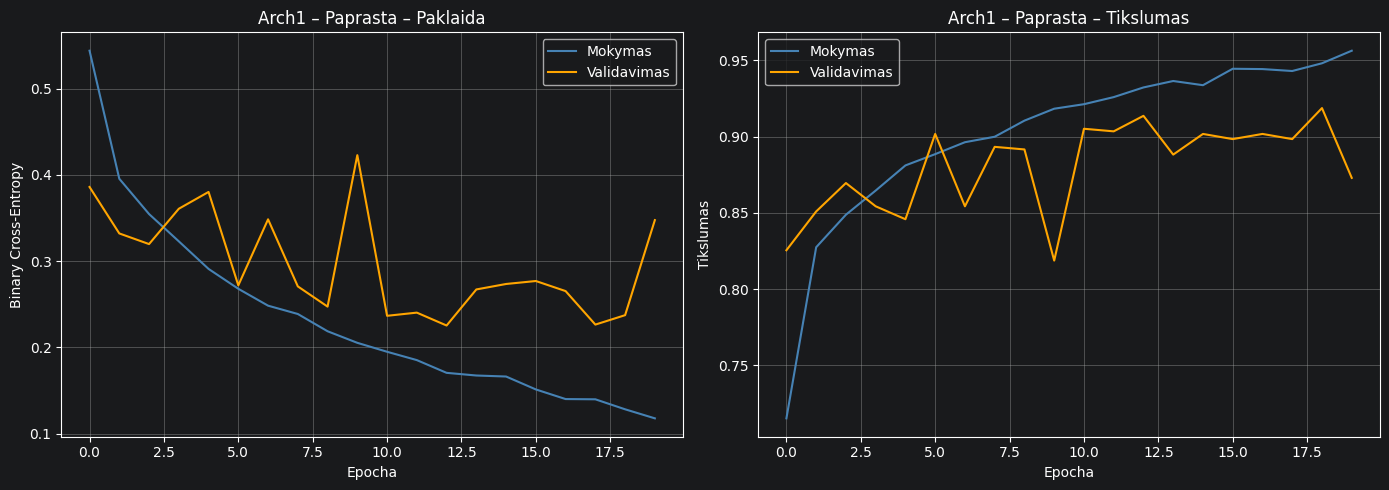

In [6]:
def sukurti_arch1(aktyvacija='relu', optimizatorius='adam',
                  dropout_tikimybe=0.0, batch_norm=False):
    modelis = keras.Sequential(name='Arch1_Paprasta')
    modelis.add(layers.Input(shape=(*IMG_DYDIS, 3)))

    # 1 konvoliucinis blokas: 32 filtrai, 3x3 branduolys
    modelis.add(layers.Conv2D(32, (3, 3), padding='same'))
    if batch_norm:
        modelis.add(layers.BatchNormalization())
    modelis.add(layers.Activation(aktyvacija))
    modelis.add(layers.MaxPooling2D((2, 2)))  # sumažina erdvinį dydį perpus

    # 2 konvoliucinis blokas: 64 filtrai
    modelis.add(layers.Conv2D(64, (3, 3), padding='same'))
    if batch_norm:
        modelis.add(layers.BatchNormalization())
    modelis.add(layers.Activation(aktyvacija))
    modelis.add(layers.MaxPooling2D((2, 2)))

    # Klasifikavimo galva
    modelis.add(layers.Flatten())
    modelis.add(layers.Dense(64, activation=aktyvacija))
    if dropout_tikimybe > 0:
        modelis.add(layers.Dropout(dropout_tikimybe))
    modelis.add(layers.Dense(1, activation='sigmoid'))  # binarinė klasifikacija

    modelis.compile(
        optimizer=optimizatorius,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return modelis

arch1 = sukurti_arch1()
hist1 = mokyti_modeli(arch1, epochu_sk=20, pavadinimas='Arch1 – Paprasta')
braizyt_rezultatus(hist1, 'Arch1 – Paprasta')


Mokomas: Arch2 – Vidutinė


Model: "Arch2_Vidutine"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,150,273 (4.39 MB)

 Trainable params: 1,150,273 (4.39 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - accuracy: 0.6492 - loss: 0.6194 - val_accuracy: 0.8492 - val_loss: 0.3908
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 112ms/step - accuracy: 0.8480 - loss: 0.3572 - val_accuracy: 0.8458 - val_loss: 0.3687
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 116ms/step - accuracy: 0.8643 - loss: 0.3174 - val_accuracy: 0.8915 - val_loss: 0.2821
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 115ms/step - accuracy: 0.8894 - loss: 0.2829 - val_accuracy: 0.8458 - val_loss: 0.3805
Epoch 5/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 114ms/step - accuracy: 0.9042 - loss: 0.2470 - val_accuracy: 0.8424 - val_loss: 0.4019
Epoch 6/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 116ms/step - accuracy: 0.9013 - loss: 0.2507 - val_accuracy: 0.8661 - val_loss: 0.3041
Epoch 7/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 114ms/step - accuracy: 0.9213 - loss: 0.2009 - val_accuracy: 0.8898 - val_loss: 0.2748
Epoch 8/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 116ms/step - accuracy: 0.9176 - loss: 0

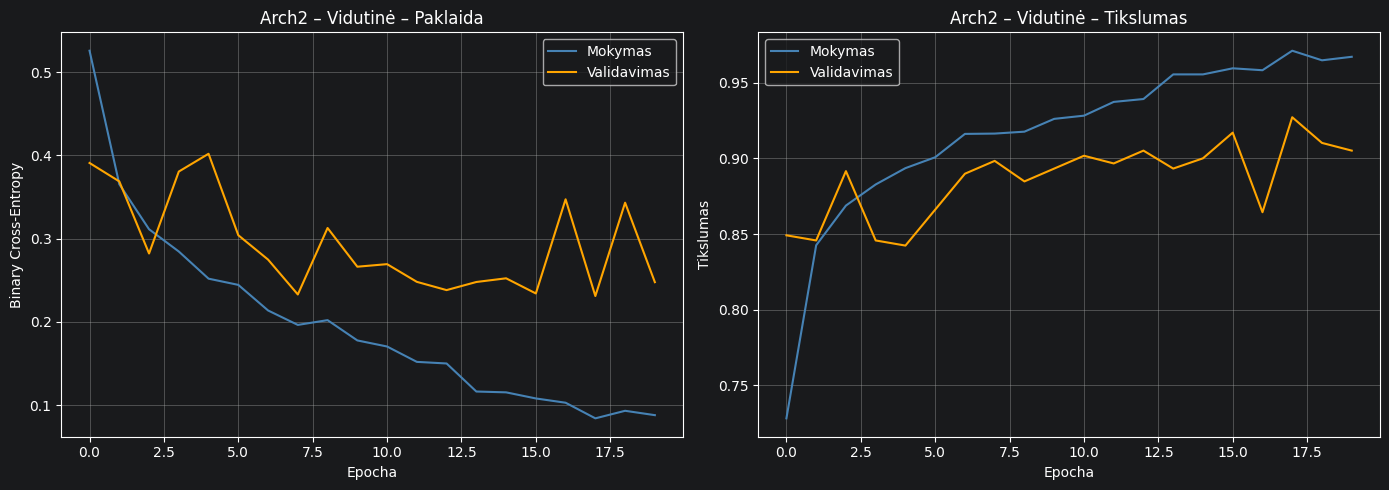

In [7]:
def sukurti_arch2(aktyvacija='relu', optimizatorius='adam',
                  dropout_tikimybe=0.0, batch_norm=False):
    modelis = keras.Sequential(name='Arch2_Vidutine')
    modelis.add(layers.Input(shape=(*IMG_DYDIS, 3)))

    # 1 blokas: 32 filtrai
    modelis.add(layers.Conv2D(32, (3, 3), padding='same'))
    if batch_norm:
        modelis.add(layers.BatchNormalization())
    modelis.add(layers.Activation(aktyvacija))
    modelis.add(layers.MaxPooling2D((2, 2)))

    # 2 blokas: 64 filtrai
    modelis.add(layers.Conv2D(64, (3, 3), padding='same'))
    if batch_norm:
        modelis.add(layers.BatchNormalization())
    modelis.add(layers.Activation(aktyvacija))
    modelis.add(layers.MaxPooling2D((2, 2)))

    # 3 blokas: 128 filtrai – išmoksta sudėtingesnius požymius
    modelis.add(layers.Conv2D(128, (3, 3), padding='same'))
    if batch_norm:
        modelis.add(layers.BatchNormalization())
    modelis.add(layers.Activation(aktyvacija))
    modelis.add(layers.MaxPooling2D((2, 2)))

    # Klasifikavimo galva su 2 tankiais sluoksniais
    modelis.add(layers.Flatten())
    modelis.add(layers.Dense(128, activation=aktyvacija))
    if dropout_tikimybe > 0:
        modelis.add(layers.Dropout(dropout_tikimybe))
    modelis.add(layers.Dense(64, activation=aktyvacija))
    if dropout_tikimybe > 0:
        modelis.add(layers.Dropout(dropout_tikimybe))
    modelis.add(layers.Dense(1, activation='sigmoid'))

    modelis.compile(
        optimizer=optimizatorius,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return modelis

arch2 = sukurti_arch2()
hist2 = mokyti_modeli(arch2, epochu_sk=20, pavadinimas='Arch2 – Vidutinė')
braizyt_rezultatus(hist2, 'Arch2 – Vidutinė')


Mokomas: Arch3 – Gili


Model: "Arch3_Gili"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,441 (1.61 MB)

 Trainable params: 421,441 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 18s 117ms/step - accuracy: 0.5904 - loss: 0.6656 - val_accuracy: 0.6915 - val_loss: 0.5760
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 16s 109ms/step - accuracy: 0.8050 - loss: 0.4456 - val_accuracy: 0.6864 - val_loss: 0.5557
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 16s 109ms/step - accuracy: 0.8368 - loss: 0.3865 - val_accuracy: 0.8627 - val_loss: 0.3651
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 16s 111ms/step - accuracy: 0.8558 - loss: 0.3558 - val_accuracy: 0.8373 - val_loss: 0.3902
Epoch 5/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 114ms/step - accuracy: 0.8760 - loss: 0.3072 - val_accuracy: 0.8695 - val_loss: 0.3271
Epoch 6/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 113ms/step - accuracy: 0.8903 - loss: 0.2836 - val_accuracy: 0.8661 - val_loss: 0.3135
Epoch 7/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 116ms/step - accuracy: 0.8976 - loss: 0.2609 - val_accuracy: 0.8780 - val_loss: 0.2795
Epoch 8/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 117ms/step - accuracy: 0.9037 - loss: 0

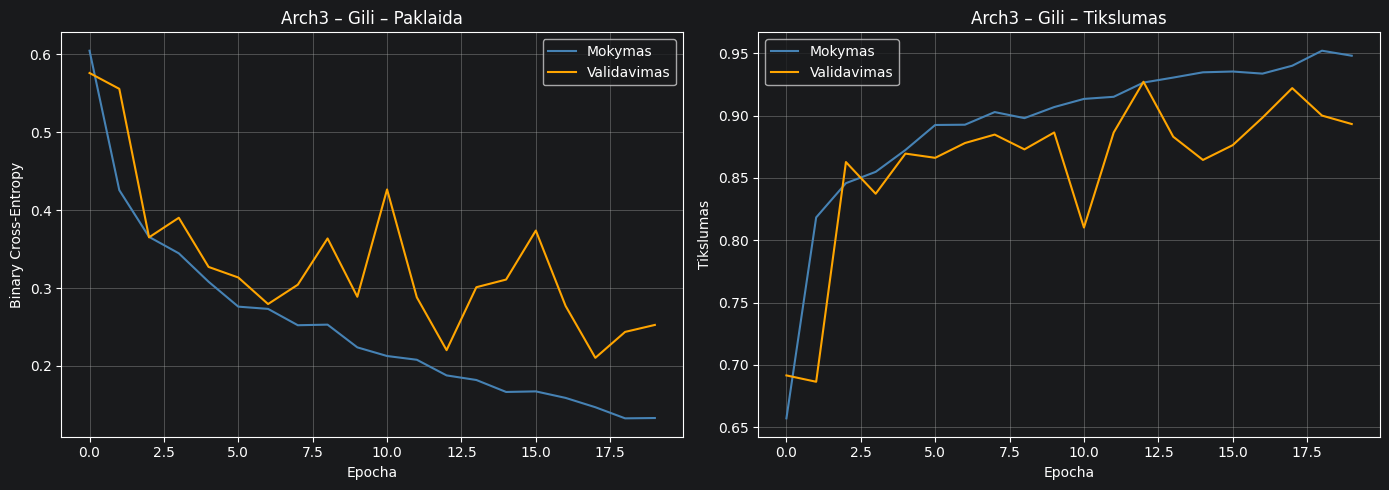

In [8]:
def sukurti_arch3(aktyvacija='relu', optimizatorius='adam',
                  dropout_tikimybe=0.0, batch_norm=False):
    modelis = keras.Sequential(name='Arch3_Gili')
    modelis.add(layers.Input(shape=(*IMG_DYDIS, 3)))

    # 4 konvoliuciniai blokai su didėjančiu filtrų skaičiumi
    for filtru_sk in [32, 64, 128, 256]:
        modelis.add(layers.Conv2D(filtru_sk, (3, 3), padding='same'))
        if batch_norm:
            modelis.add(layers.BatchNormalization())
        modelis.add(layers.Activation(aktyvacija))
        modelis.add(layers.MaxPooling2D((2, 2)))

    # GlobalAveragePooling vietoj Flatten – mažiau parametrų,
    # geriau kovoja su persimokimu
    modelis.add(layers.GlobalAveragePooling2D())
    modelis.add(layers.Dense(128, activation=aktyvacija))
    if dropout_tikimybe > 0:
        modelis.add(layers.Dropout(dropout_tikimybe))
    modelis.add(layers.Dense(1, activation='sigmoid'))

    modelis.compile(
        optimizer=optimizatorius,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return modelis

arch3 = sukurti_arch3()
hist3 = mokyti_modeli(arch3, epochu_sk=20, pavadinimas='Arch3 – Gili')
braizyt_rezultatus(hist3, 'Arch3 – Gili')


Mokomas: Dropout=0.0


Model: "Arch2_Vidutine"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,150,273 (4.39 MB)

 Trainable params: 1,150,273 (4.39 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,150,273 (4.39 MB)

 Trainable params: 1,150,273 (4.39 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 25s 156ms/step - accuracy: 0.5514 - loss: 0.6987 - val_accuracy: 0.7915 - val_loss: 0.4960
Epoch 2/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 21s 141ms/step - accuracy: 0.7402 - loss: 0.5390 - val_accuracy: 0.8220 - val_loss: 0.4175
Epoch 3/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 21s 142ms/step - accuracy: 0.8151 - loss: 0.4298 - val_accuracy: 0.8644 - val_loss: 0.3368
Epoch 4/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 28s 190ms/step - accuracy: 0.8437 - loss: 0.3750 - val_accuracy: 0.8508 - val_loss: 0.3480
Epoch 5/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 44s 298ms/step - accuracy: 0.8636 - loss: 0.3421 - val_accuracy: 0.8559 - val_loss: 0.3636
Epoch 6/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 28s 189ms/step - accuracy: 0.8560 - loss: 0.3443 - val_accuracy: 0.8932 - val_loss: 0.2978
Epoch 7/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 28s 189ms/step - accuracy: 0.8705 - loss: 0.3074 - val_accuracy: 0.8915 - val_loss: 0.2958
Epoch 8/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 40s 268ms/step - accuracy: 0.8972 - loss: 0

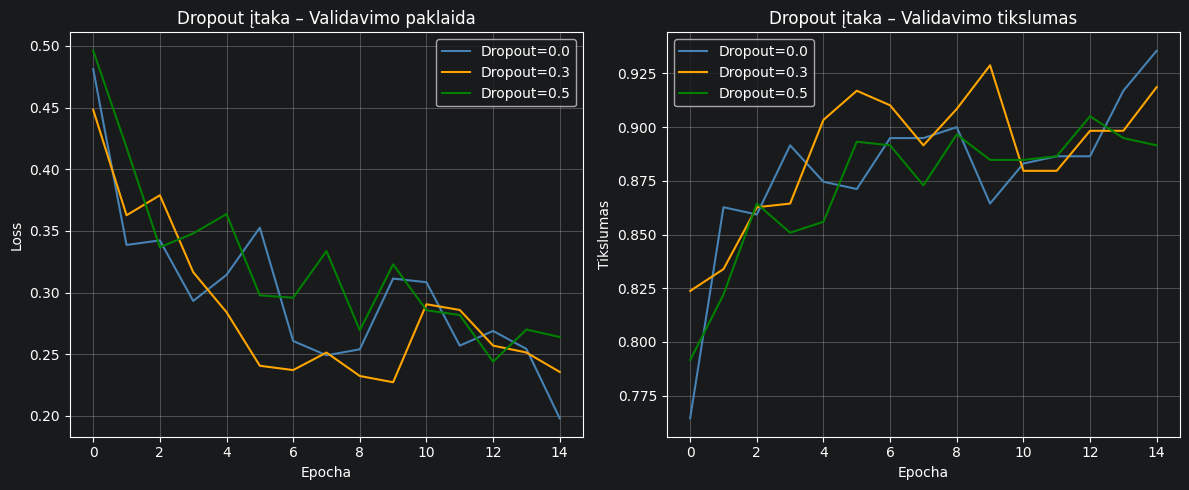

In [9]:
dropout_reiksmes = [0.0, 0.3, 0.5]
dropout_rezultatai = {}

for dp in dropout_reiksmes:
    pavadinimas = f'Dropout={dp}'
    m = sukurti_arch2(dropout_tikimybe=dp)
    h = mokyti_modeli(m, epochu_sk=15, pavadinimas=pavadinimas)
    dropout_rezultatai[dp] = h

# Palyginimo grafikas
plt.figure(figsize=(12, 5))
spalvos = ['steelblue', 'orange', 'green']

for (dp, h), spalva in zip(dropout_rezultatai.items(), spalvos):
    plt.subplot(1, 2, 1)
    plt.plot(h.history['val_loss'], label=f'Dropout={dp}', color=spalva)
    plt.subplot(1, 2, 2)
    plt.plot(h.history['val_accuracy'], label=f'Dropout={dp}', color=spalva)

plt.subplot(1, 2, 1)
plt.title('Dropout įtaka – Validavimo paklaida')
plt.xlabel('Epocha'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.title('Dropout įtaka – Validavimo tikslumas')
plt.xlabel('Epocha'); plt.ylabel('Tikslumas'); plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()


Mokomas: Be BatchNorm


Model: "Arch2_Vidutine"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,150,273 (4.39 MB)

 Trainable params: 1,150,273 (4.39 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,151,169 (4.39 MB)

 Trainable params: 1,150,721 (4.39 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 130ms/step - accuracy: 0.7558 - loss: 0.6960 - val_accuracy: 0.5407 - val_loss: 1.5121
Epoch 2/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 19s 131ms/step - accuracy: 0.8684 - loss: 0.3238 - val_accuracy: 0.5407 - val_loss: 2.7415
Epoch 3/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 132ms/step - accuracy: 0.8826 - loss: 0.2809 - val_accuracy: 0.6000 - val_loss: 1.0071
Epoch 4/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 19s 131ms/step - accuracy: 0.9026 - loss: 0.2502 - val_accuracy: 0.5797 - val_loss: 1.3904
Epoch 5/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 132ms/step - accuracy: 0.8994 - loss: 0.2583 - val_accuracy: 0.6712 - val_loss: 0.6190
Epoch 6/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 19s 131ms/step - accuracy: 0.9085 - loss: 0.2233 - val_accuracy: 0.7814 - val_loss: 0.5406
Epoch 7/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 135ms/step - accuracy: 0.9231 - loss: 0.1976 - val_accuracy: 0.7237 - val_loss: 0.6772
Epoch 8/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 133ms/step - accuracy: 0.9312 - loss: 0

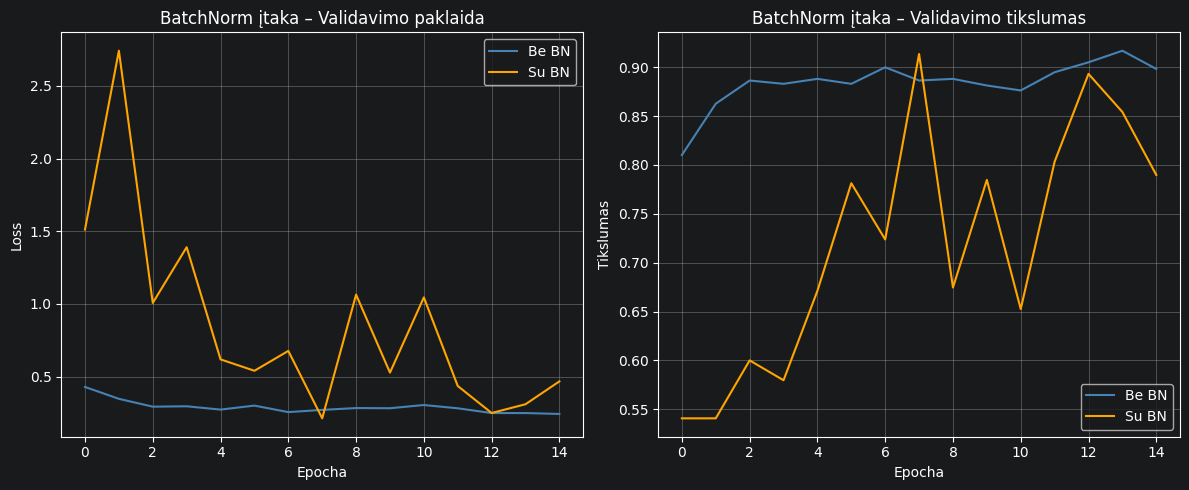

In [10]:
m_be_bn = sukurti_arch2(batch_norm=False)
m_su_bn = sukurti_arch2(batch_norm=True)

h_be_bn = mokyti_modeli(m_be_bn, epochu_sk=15, pavadinimas='Be BatchNorm')
h_su_bn = mokyti_modeli(m_su_bn, epochu_sk=15, pavadinimas='Su BatchNorm')

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(h_be_bn.history['val_loss'], label='Be BN', color='steelblue')
plt.plot(h_su_bn.history['val_loss'], label='Su BN', color='orange')
plt.title('BatchNorm įtaka – Validavimo paklaida')
plt.xlabel('Epocha'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(h_be_bn.history['val_accuracy'], label='Be BN', color='steelblue')
plt.plot(h_su_bn.history['val_accuracy'], label='Su BN', color='orange')
plt.title('BatchNorm įtaka – Validavimo tikslumas')
plt.xlabel('Epocha'); plt.ylabel('Tikslumas'); plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()


Mokomas: Aktyvacija=relu


Model: "Arch2_Vidutine"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,150,273 (4.39 MB)

 Trainable params: 1,150,273 (4.39 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_30 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_31 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_32 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,150,273 (4.39 MB)

 Trainable params: 1,150,273 (4.39 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 19s 126ms/step - accuracy: 0.6897 - loss: 0.6372 - val_accuracy: 0.8169 - val_loss: 0.4075
Epoch 2/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 18s 124ms/step - accuracy: 0.8398 - loss: 0.3673 - val_accuracy: 0.8220 - val_loss: 0.4063
Epoch 3/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 19s 126ms/step - accuracy: 0.8675 - loss: 0.3181 - val_accuracy: 0.8085 - val_loss: 0.4121
Epoch 4/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 18s 123ms/step - accuracy: 0.8616 - loss: 0.3157 - val_accuracy: 0.8390 - val_loss: 0.3548
Epoch 5/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 18s 123ms/step - accuracy: 0.8955 - loss: 0.2648 - val_accuracy: 0.8576 - val_loss: 0.3370
Epoch 6/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 18s 123ms/step - accuracy: 0.8986 - loss: 0.2319 - val_accuracy: 0.8203 - val_loss: 0.4312
Epoch 7/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 19s 125ms/step - accuracy: 0.9062 - loss: 0.2249 - val_accuracy: 0.8983 - val_loss: 0.2691
Epoch 8/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 18s 123ms/step - accuracy: 0.9304 - loss: 0

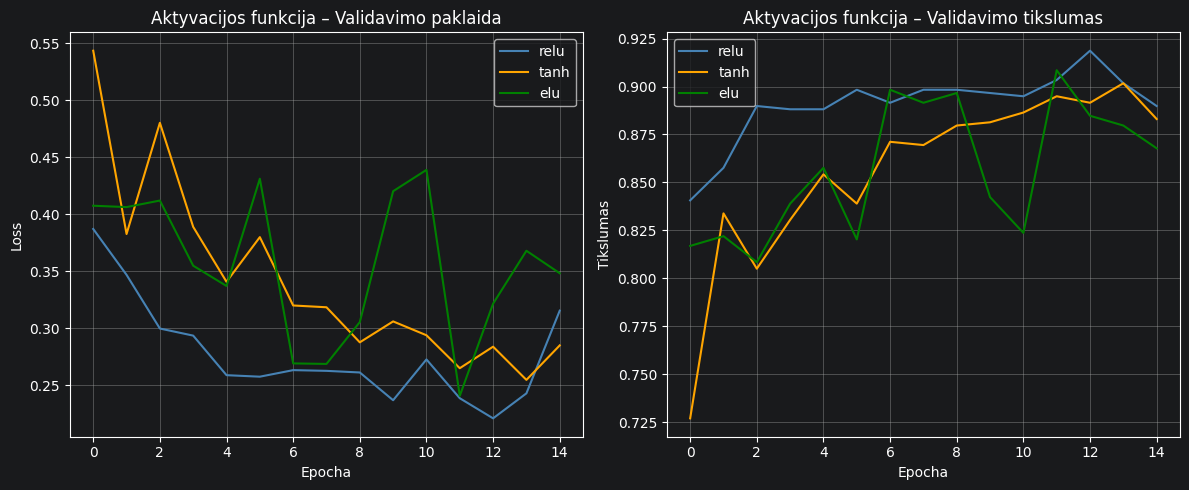

In [11]:
aktyvacijos = ['relu', 'tanh', 'elu']
aktyvacijos_rezultatai = {}
spalvos = ['steelblue', 'orange', 'green']

for akt in aktyvacijos:
    m = sukurti_arch2(aktyvacija=akt)
    h = mokyti_modeli(m, epochu_sk=15, pavadinimas=f'Aktyvacija={akt}')
    aktyvacijos_rezultatai[akt] = h

plt.figure(figsize=(12, 5))

for (akt, h), spalva in zip(aktyvacijos_rezultatai.items(), spalvos):
    plt.subplot(1, 2, 1)
    plt.plot(h.history['val_loss'], label=akt, color=spalva)
    plt.subplot(1, 2, 2)
    plt.plot(h.history['val_accuracy'], label=akt, color=spalva)

plt.subplot(1, 2, 1)
plt.title('Aktyvacijos funkcija – Validavimo paklaida')
plt.xlabel('Epocha'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.title('Aktyvacijos funkcija – Validavimo tikslumas')
plt.xlabel('Epocha'); plt.ylabel('Tikslumas'); plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()


Mokomas: Optimizatorius=adam


Model: "Arch2_Vidutine"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_33 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_33 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_34 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_35 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,150,273 (4.39 MB)

 Trainable params: 1,150,273 (4.39 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_39 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_39 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_40 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_41 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,150,273 (4.39 MB)

 Trainable params: 1,150,273 (4.39 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 18s 117ms/step - accuracy: 0.6321 - loss: 0.6749 - val_accuracy: 0.6780 - val_loss: 0.7410
Epoch 2/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 116ms/step - accuracy: 0.7951 - loss: 0.4565 - val_accuracy: 0.8746 - val_loss: 0.3361
Epoch 3/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 118ms/step - accuracy: 0.8349 - loss: 0.3780 - val_accuracy: 0.8729 - val_loss: 0.3107
Epoch 4/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 18s 118ms/step - accuracy: 0.8686 - loss: 0.3195 - val_accuracy: 0.8644 - val_loss: 0.3041
Epoch 5/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 118ms/step - accuracy: 0.8787 - loss: 0.2953 - val_accuracy: 0.8949 - val_loss: 0.2738
Epoch 6/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 18s 119ms/step - accuracy: 0.8871 - loss: 0.2661 - val_accuracy: 0.8661 - val_loss: 0.3051
Epoch 7/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 18s 119ms/step - accuracy: 0.8956 - loss: 0.2462 - val_accuracy: 0.8508 - val_loss: 0.3616
Epoch 8/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 18s 120ms/step - accuracy: 0.8977 - loss: 0

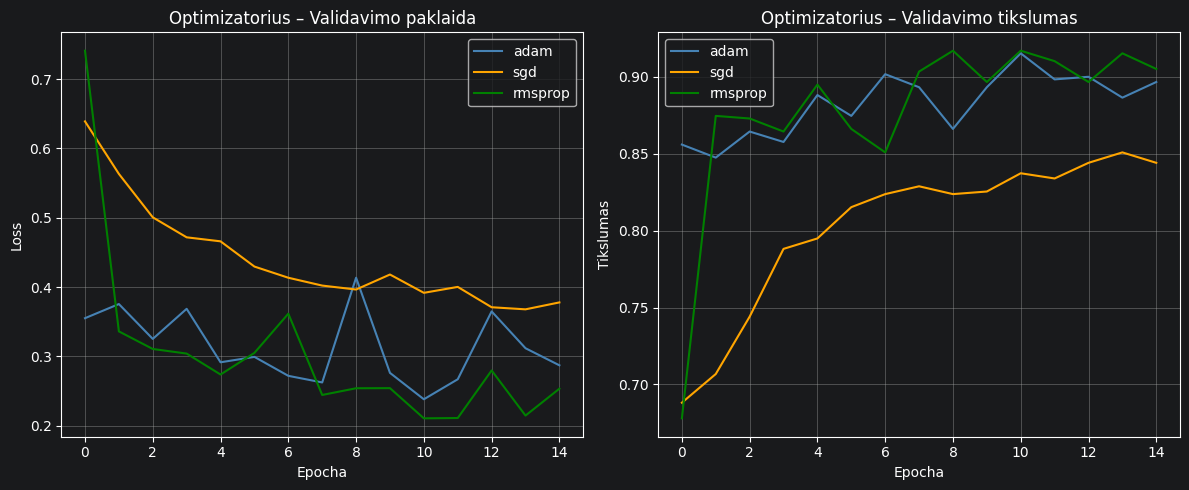

In [12]:
optimizatoriai = ['adam', 'sgd', 'rmsprop']
optim_rezultatai = {}
spalvos = ['steelblue', 'orange', 'green']

for opt in optimizatoriai:
    m = sukurti_arch2(optimizatorius=opt)
    h = mokyti_modeli(m, epochu_sk=15, pavadinimas=f'Optimizatorius={opt}')
    optim_rezultatai[opt] = h

plt.figure(figsize=(12, 5))

for (opt, h), spalva in zip(optim_rezultatai.items(), spalvos):
    plt.subplot(1, 2, 1)
    plt.plot(h.history['val_loss'], label=opt, color=spalva)
    plt.subplot(1, 2, 2)
    plt.plot(h.history['val_accuracy'], label=opt, color=spalva)

plt.subplot(1, 2, 1)
plt.title('Optimizatorius – Validavimo paklaida')
plt.xlabel('Epocha'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.title('Optimizatorius – Validavimo tikslumas')
plt.xlabel('Epocha'); plt.ylabel('Tikslumas'); plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()


Mokomas: Geriausias modelis


Model: "Arch2_Vidutine"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_42 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_42 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_43 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_44 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,150,273 (4.39 MB)

 Trainable params: 1,150,273 (4.39 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 18s 117ms/step - accuracy: 0.5969 - loss: 0.6666 - val_accuracy: 0.8085 - val_loss: 0.4571
Epoch 2/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 16s 111ms/step - accuracy: 0.7938 - loss: 0.4668 - val_accuracy: 0.8712 - val_loss: 0.3262
Epoch 3/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 111ms/step - accuracy: 0.8464 - loss: 0.3831 - val_accuracy: 0.8610 - val_loss: 0.3131
Epoch 4/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 116ms/step - accuracy: 0.8581 - loss: 0.3493 - val_accuracy: 0.8949 - val_loss: 0.2842
Epoch 5/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 16s 109ms/step - accuracy: 0.8727 - loss: 0.3087 - val_accuracy: 0.8678 - val_loss: 0.3205
Epoch 6/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 16s 108ms/step - accuracy: 0.8862 - loss: 0.2779 - val_accuracy: 0.8932 - val_loss: 0.2788
Epoch 7/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 16s 109ms/step - accuracy: 0.8984 - loss: 0.2537 - val_accuracy: 0.8949 - val_loss: 0.2615
Epoch 8/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 16s 109ms/step - accuracy: 0.9083 - loss: 0

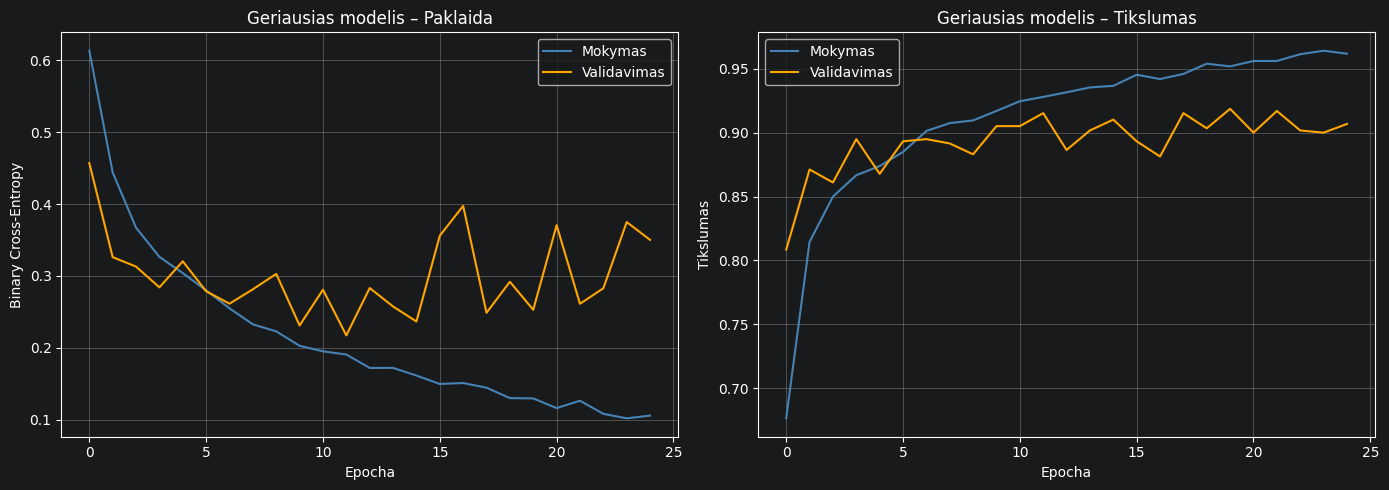

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step

Geriausias modelis – Testavimo tikslumas: 0.8990


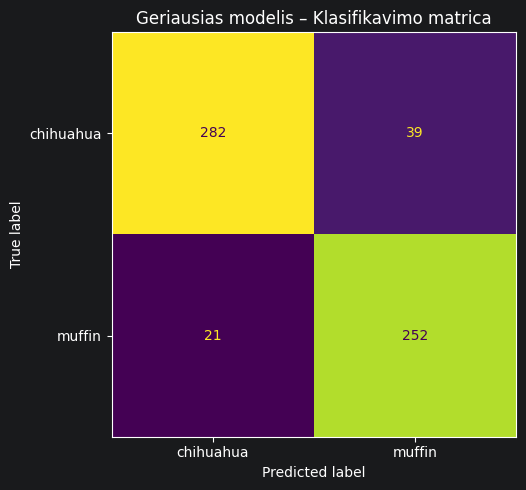

np.float64(0.898989898989899)

In [13]:
geriausias_modelis = sukurti_arch2(
    aktyvacija='relu',
    optimizatorius='rmsprop',
    dropout_tikimybe=0.3,
    batch_norm=False
)

hist_geriausias = mokyti_modeli(geriausias_modelis, epochu_sk=25,
                                pavadinimas='Geriausias modelis')
braizyt_rezultatus(hist_geriausias, 'Geriausias modelis')

# Testavimo tikslumas ir confusion matrix
ivertinti_ir_cm(geriausias_modelis, 'Geriausias modelis')

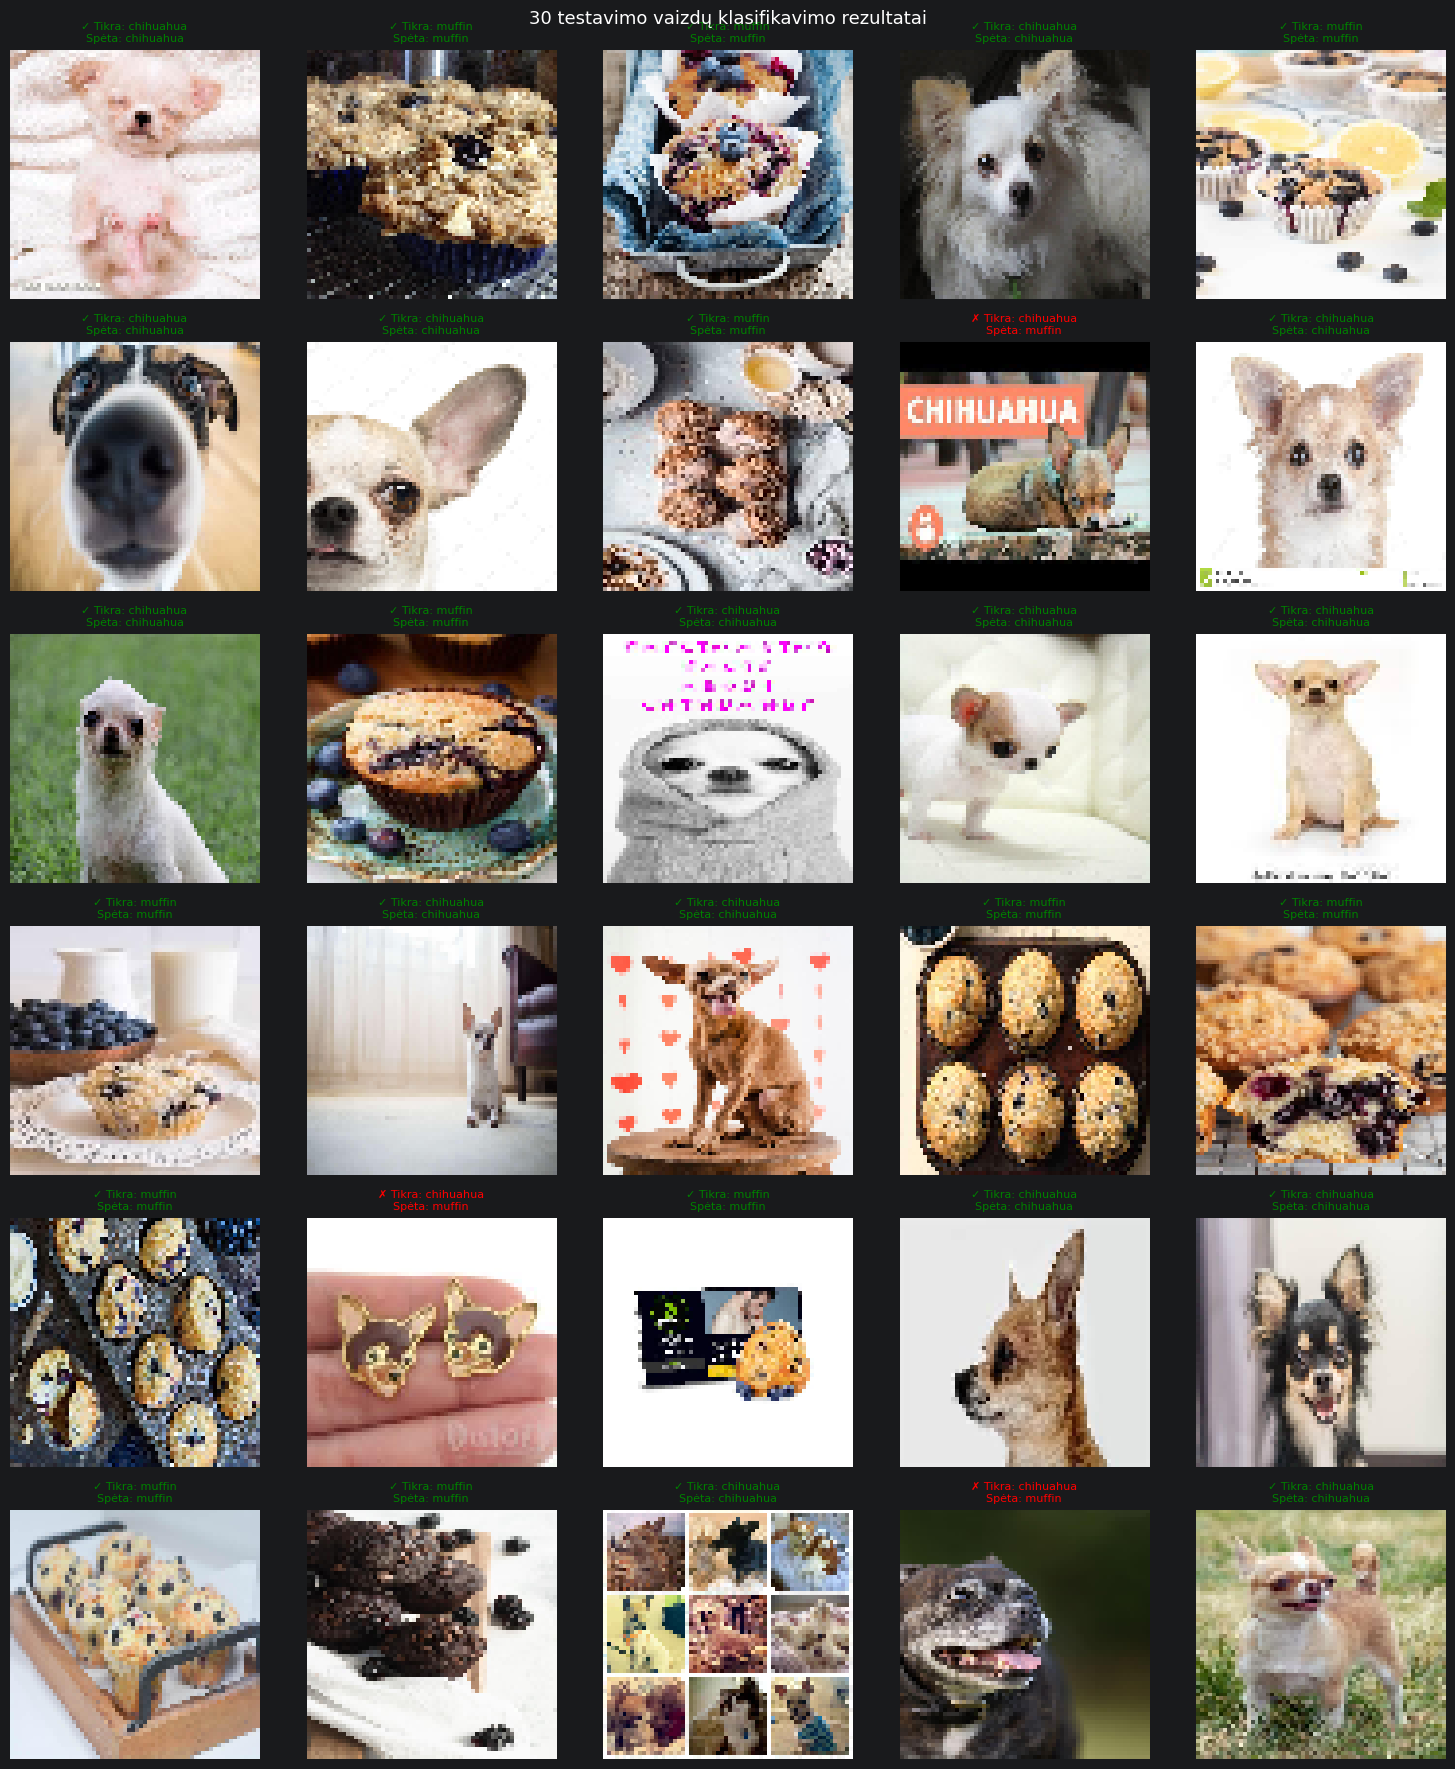

In [14]:
from tensorflow.keras.preprocessing import image as keras_image

def rodyti_pavyzdzius(modelis, test_katalogas, klases, kiekis=30):
    visi = []
    for klase in klases:
        kat = os.path.join(test_katalogas, klase)
        for f in os.listdir(kat):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                visi.append((os.path.join(kat, f), klase))

    pasirinkti = random.sample(visi, min(kiekis, len(visi)))

    fig, axes = plt.subplots(6, 5, figsize=(15, 18))
    axes = axes.flatten()

    for i, (kelias, tikra) in enumerate(pasirinkti):
        img = keras_image.load_img(kelias, target_size=IMG_DYDIS)
        arr = keras_image.img_to_array(img) / 255.0
        prob = modelis.predict(np.expand_dims(arr, 0), verbose=0)[0][0]
        nusp = klases[1] if prob > 0.5 else klases[0]
        teisinga = '✓' if nusp == tikra else '✗'
        spalva = 'green' if nusp == tikra else 'red'

        axes[i].imshow(img)
        axes[i].set_title(f'{teisinga} Tikra: {tikra}\nSpėta: {nusp}',
                          color=spalva, fontsize=8)
        axes[i].axis('off')

    plt.suptitle('30 testavimo vaizdų klasifikavimo rezultatai', fontsize=13)
    plt.tight_layout()
    plt.show()

rodyti_pavyzdzius(
    geriausias_modelis,
    os.path.join(ISVESTIES_KATALOGAS, 'test'),
    KLASES
)